# (7주차) 10월13일 -- draft
> 딥러닝의 기초 - 깊은신경망(5)-- 드랍아웃, 드랍아웃 with fastai

- toc:true
- branch: master
- badges: true
- comments: true
- author: 최규빈

## 강의영상 

## imports

In [1]:
import torch
from fastai.vision.all import *
import matplotlib.pyplot as plt

## 드랍아웃 

### 지난시간리뷰

#### `#` 데이터

model: $y_i = (0\times x_i) + \epsilon_i$, where $\epsilon_i \sim N(0,0.01^2)$

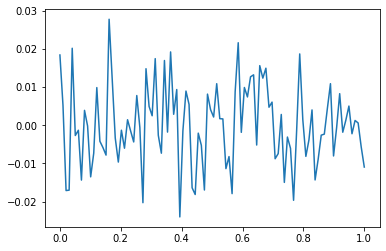

In [2]:
torch.manual_seed(5) 
x=torch.linspace(0,1,100).reshape(100,1)
y=torch.randn(100).reshape(100,1)*0.01
plt.plot(x,y)

#### `#` 모든 데이터를 사용하여 적합 (512 nodes, relu, 1000 epochs)

In [3]:
torch.manual_seed(1) 
net = torch.nn.Sequential(
    torch.nn.Linear(in_features=1,out_features=512),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=512,out_features=1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())

for epoc in range(1000):
    ## 1 
    yhat = net(x) 
    ## 2 
    loss = loss_fn(yhat,y) 
    ## 3 
    loss.backward()
    ## 4 
    optimizr.step()
    optimizr.zero_grad()

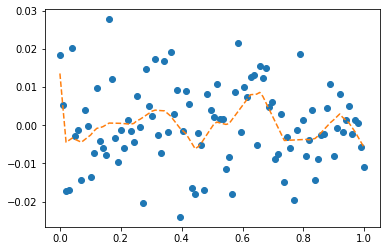

In [4]:
plt.plot(x,y,'o')
plt.plot(x,net(x).data,'--')

#### `#` training/test 를 8:2 로 분리하여 학습

`-` 데이터를 분리 

In [5]:
xtr = x[:80]
xtest = x[80:]
ytr = y[:80]
ytest = y[80:] 

In [6]:
x.shape,xtr.shape,xtest.shape

(torch.Size([100, 1]), torch.Size([80, 1]), torch.Size([20, 1]))

In [7]:
y.shape,ytr.shape,ytest.shape

(torch.Size([100, 1]), torch.Size([80, 1]), torch.Size([20, 1]))

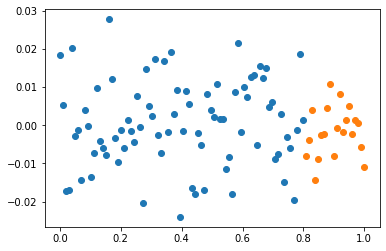

In [8]:
plt.plot(xtr,ytr,'o')
plt.plot(xtest,ytest,'o')

`-` training data 만 이용하여 네트워크 학습 (처음 80개의 자료만 이용하여 네트워크 학습)

In [9]:
torch.manual_seed(1) 
net = torch.nn.Sequential(
    torch.nn.Linear(in_features=1,out_features=512),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=512,out_features=1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())

for epoc in range(1000):
    ## 1 
    ## 2 
    loss = loss_fn(net(xtr),ytr) 
    ## 3 
    loss.backward()
    ## 4 
    optimizr.step()
    optimizr.zero_grad()

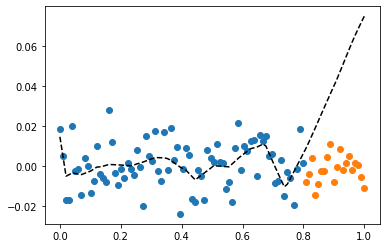

In [10]:
plt.plot(xtr,ytr,'o')
plt.plot(xtest,ytest,'o')
plt.plot(x,net(x).data,'--k')

### 드랍아웃 

#### `#` 드랍아웃 레이어를 쓰면? 

In [11]:
torch.manual_seed(1) 
net = torch.nn.Sequential(
    torch.nn.Linear(in_features=1,out_features=512),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.8),
    torch.nn.Linear(in_features=512,out_features=1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())

for epoc in range(1000):
    ## 1 
    ## 2 
    loss = loss_fn(net(xtr),ytr) 
    ## 3 
    loss.backward()
    ## 4 
    optimizr.step()
    optimizr.zero_grad()

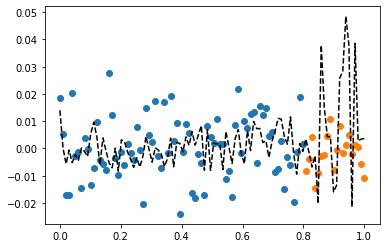

In [12]:
plt.plot(xtr,ytr,'o')
plt.plot(xtest,ytest,'o')
plt.plot(x,net(x).data,'--k')

- ??? 네트워크의 결과가 왜 랜덤으로 나와?? 

아래와 같이 수정해야한다. 

In [13]:
net.training

True

In [14]:
net.eval()
net.training

False

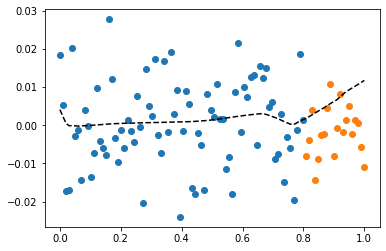

In [15]:
plt.plot(xtr,ytr,'o')
plt.plot(xtest,ytest,'o')
plt.plot(x,net.eval()(x).data,'--k')

#### `#` 드랍아웃 레이어

`-` 드랍아웃 레이어의 동작살펴보기

In [16]:
torch.manual_seed(43052)
d1 = torch.nn.Dropout(0.9) ## 드랍아웃
torch.linspace(0,1,101), d1(torch.linspace(0,1,101))

(tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
         0.0900, 0.1000, 0.1100, 0.1200, 0.1300, 0.1400, 0.1500, 0.1600, 0.1700,
         0.1800, 0.1900, 0.2000, 0.2100, 0.2200, 0.2300, 0.2400, 0.2500, 0.2600,
         0.2700, 0.2800, 0.2900, 0.3000, 0.3100, 0.3200, 0.3300, 0.3400, 0.3500,
         0.3600, 0.3700, 0.3800, 0.3900, 0.4000, 0.4100, 0.4200, 0.4300, 0.4400,
         0.4500, 0.4600, 0.4700, 0.4800, 0.4900, 0.5000, 0.5100, 0.5200, 0.5300,
         0.5400, 0.5500, 0.5600, 0.5700, 0.5800, 0.5900, 0.6000, 0.6100, 0.6200,
         0.6300, 0.6400, 0.6500, 0.6600, 0.6700, 0.6800, 0.6900, 0.7000, 0.7100,
         0.7200, 0.7300, 0.7400, 0.7500, 0.7600, 0.7700, 0.7800, 0.7900, 0.8000,
         0.8100, 0.8200, 0.8300, 0.8400, 0.8500, 0.8600, 0.8700, 0.8800, 0.8900,
         0.9000, 0.9100, 0.9200, 0.9300, 0.9400, 0.9500, 0.9600, 0.9700, 0.9800,
         0.9900, 1.0000]),
 tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
 

In [17]:
torch.linspace(0,1,101).sum(), d1(torch.linspace(0,1,101)).sum()

(tensor(50.5000), tensor(23.3000))

- 90% 드랍아웃: 드랍아웃의 입력중 임의로 90%를 골라서 결과를 0으로 만든다. -> 대신 살아남은 값들은 `*10`배 만큼 해주어 전체 신호의 총량은 어느정도 비슷하게 맞추어준다. 

`-` 드랍아웃레이어 
- 구조: 입력 -> 드랍아웃 레이어 -> 출력 
- 역할: (1) 입력의 일부를 임의로 0으로 만드는 역할 (2) 0이 안된것들은 스칼라배하여 드랍아웃을 통과한 모든 숫자의 합이 일정하도록 조정 
- 효과: 오버피팅을 억제하는 효과가 있음 (왜?)
- 의미: each iteration (each epoc X) 마다 학습에 참여하는 노드가 로테이션으로 랜덤하게 결정됨 
- 느낌: 모든 노드가 골고루 학습가능 + 한 두개 특화된 능력치가 개발되기 보다 평균적인 능력치가 전반적으로 개선됨 

`-` 드랍아웃레이어가 포함된 네트워크를 이용하는 방법 
- 학습모드: 랜덤으로 노드를 보낸다. (모든 노드를 고르게 학습 + 평균적인 능력치를 높이기 위함 // 학습은 개인적으로)
- 평가모드: 모든 노드를 참여시켜 평가한다. (그러니까 평가할떄는 드랍아웃 레이어를 쓰지 않는다는 의미 // 평가는 합주로) 
- 요약: 학습모드에서는 드랍아웃 레이어를 동작시키고, 평가모드에서는 드랍아웃 레이어를 통과시키지 않는다. 

## fastai를 이용한 구현 

### 모티브 

`-` 확률적경사하강법: 

### 구현 

`-` 데이터확인 

In [18]:
xtr.shape, ytr.shape, xtest.shape, ytest.shape

(torch.Size([80, 1]),
 torch.Size([80, 1]),
 torch.Size([20, 1]),
 torch.Size([20, 1]))

`-` [dl_tr, dl_test] -> dls 

In [19]:
ds_tr = torch.utils.data.TensorDataset(xtr,ytr)
ds_test = torch.utils.data.TensorDataset(xtest,ytest)
dl_tr = torch.utils.data.DataLoader(ds_tr, batch_size=80) 
dl_test = torch.utils.data.DataLoader(ds_test, batch_size=20) 
dls = DataLoaders(dl_tr, dl_test) 

#### `#` 드랍아웃 안쓴거 

In [46]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(in_features=1, out_features=512),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=512,out_features=1)
)
loss_fn = torch.nn.MSELoss()
# optimizr = torch.optim.Adam(net.parameters()) 필요없음.. 지가 알아서 아담으로 잡아줌

In [47]:
lrnr= Learner(dls,net,loss_fn) 

In [48]:
#collapse_output
lrnr.fit(1000)

epoch,train_loss,valid_loss,time
0,0.004219,0.030030,00:00
1,0.007163,0.011353,00:00
2,0.005862,0.000204,00:00
3,0.004671,0.002421,00:00
4,0.004584,0.003163,00:00
5,0.004378,0.000876,00:00
6,0.003822,0.000112,00:00
7,0.003372,0.000911,00:00
8,0.003219,0.000645,00:00
9,0.003126,0.000097,00:00


In [49]:
net.to("cpu")

Sequential(
  (0): Linear(in_features=1, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

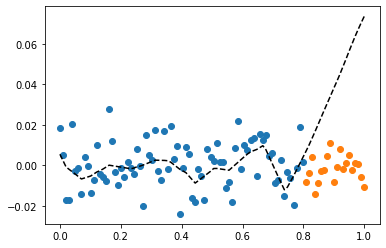

In [50]:
plt.plot(xtr,ytr,'o')
plt.plot(xtest,ytest,'o')
plt.plot(x,net(x).data,'--k')

#### `#` 드랍아웃 쓴거 

In [75]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(in_features=1, out_features=512),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.8),
    torch.nn.Linear(in_features=512,out_features=1)
)
loss_fn = torch.nn.MSELoss()

In [76]:
lrnr= Learner(dls,net,loss_fn) 

In [77]:
#collapse_output
lrnr.fit(1000)

epoch,train_loss,valid_loss,time
0,0.243213,0.003893,00:00
1,0.254278,0.006098,00:00
2,0.237203,0.004169,00:00
3,0.220325,0.002318,00:00
4,0.215824,0.000283,00:00
5,0.201916,0.000045,00:00
6,0.200752,0.000041,00:00
7,0.199367,0.000108,00:00
8,0.199736,0.001090,00:00
9,0.195443,0.002352,00:00


In [78]:
net.to("cpu")

Sequential(
  (0): Linear(in_features=1, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.8, inplace=False)
  (3): Linear(in_features=512, out_features=1, bias=True)
)

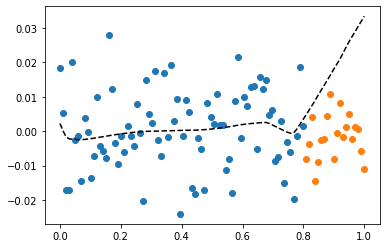

In [79]:
plt.plot(xtr,ytr,'o')
plt.plot(xtest,ytest,'o')
plt.plot(x,net(x).data,'--k')